In [1]:
#COVID-19 Data Explorer
#Project - Exploratory Data Analysis
# Author: venkateswarlu kuruva
# Date: July 2026

In [3]:
#Import all lib we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Make charts appear inside notebook
%matplotlib inline

#Make charts look better
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("All lib loaded")

Matplotlib is building the font cache; this may take a moment.


All lib loaded


In [4]:
#Load the covid-19 dataset
df = pd.read_csv('../data/covid_19_clean_complete.csv')

print(" Dataset loaded")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

 Dataset loaded
Total Rows: 49068
Total Columns: 10


In [5]:
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [6]:
#Column names
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'WHO Region']


In [7]:
#see data types of each column
print("Data Types:")
print(df.dtypes)

Data Types:
Province/State        str
Country/Region        str
Lat               float64
Long              float64
Date                  str
Confirmed           int64
Deaths              int64
Recovered           int64
Active              int64
WHO Region            str
dtype: object


In [8]:
#See statistics 
print("Basic Statistics:")
df.describe()

Basic Statistics:


,Lat,Long,Confirmed,Deaths,Recovered,Active
count,49068.000000,49068.000000,4.906800e+04,49068.000000,4.906800e+04,4.906800e+04
mean,21.433730,23.528236,1.688490e+04,884.179160,7.915713e+03,8.085012e+03
std,24.950320,70.442740,1.273002e+05,6313.584411,5.480092e+04,7.625890e+04
min,-51.796300,-135.000000,0.000000e+00,0.000000,0.000000e+00,-1.400000e+01
25%,7.873054,-15.310100,4.000000e+00,0.000000,0.000000e+00,0.000000e+00
50%,23.634500,21.745300,1.680000e+02,2.000000,2.900000e+01,2.600000e+01
75%,41.204380,80.771797,1.518250e+03,30.000000,6.660000e+02,6.060000e+02
max,71.706900,178.065000,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06


In [9]:
#Check how many missing values in each column
print(" Missing Values Per Columns:")
missing=df.isnull().sum()
print(missing)

print(f"Total missing values: {df.isnull().sum().sum()}")

 Missing Values Per Columns:
Province/State    34404
Country/Region        0
Lat                   0
Long                  0
Date                  0
Confirmed             0
Deaths                0
Recovered             0
Active                0
WHO Region            0
dtype: int64
Total missing values: 34404


In [11]:
#Fixing the data
df['Date'] = pd.to_datetime(df['Date'])

#verify it
print("Date Column fixed")
print(f"Date Column type is now: {df['Date'].dtypes}")
print(f"\nEarliest date: {df['Date'].min()}")
print(f"Latest date: {df['Date'].max()}")

Date Column fixed
Date Column type is now: datetime64[us]

Earliest date: 2020-01-22 00:00:00
Latest date: 2020-07-27 00:00:00


In [12]:
#Fill missing values Province with Unknown
df['Province/State'] = df['Province/State'].fillna('Unknown')

#Verify
print("Missing values handled")
print("\nMissing values now:")
print(df.isnull().sum())

Missing values handled

Missing values now:
Province/State    0
Country/Region    0
Lat               0
Long              0
Date              0
Confirmed         0
Deaths            0
Recovered         0
Active            0
WHO Region        0
dtype: int64


In [13]:
#Checking duplicate rows
print(f"Duplicates before: {df.duplicated().sum()}")

#Remove duplicates
df =df.drop_duplicates()

#Confirm
print(f"Duplicates after: {df.duplicated().sum()}")
print(f"Clean dataset shape: {df.shape}")

Duplicates before: 0
Duplicates after: 0
Clean dataset shape: (49068, 10)


In [14]:
#Rename columns to clearer names
df.rename(columns={
    'Province/State' : 'Province',
    'Country/Region' : 'Country',
    'WHO Region' : 'WHO_Region'
}, inplace=True)

#Confirm
print("Columns renamed")
print("\nNew column names:")
print(df.columns.tolist())

Columns renamed

New column names:
['Province', 'Country', 'Lat', 'Long', 'Date', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'WHO_Region']


In [19]:
#Create new columns for charts
df['Death_Rate'] = round((df['Deaths'] / df['Confirmed']) * 100, 2)
df['Recovery_Rate'] = round((df['Recovered'] / df['Confirmed']) * 100, 2)

df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

df['Death_Rate'] = df['Death_Rate'].fillna(0)
df['Recovery_Rate'] = df['Recovery_Rate'].fillna(0)

print("New column created")
print("\nUpdated columns")
print(df.columns.tolist())
print(f"\nSample Death Rate: {df['Death_Rate'].mean():.2f}%")
print(f"\nSample Recovery Rate: {df['Recovery_Rate'].mean():.2f}%")

New column created

Updated columns
['Province', 'Country', 'Lat', 'Long', 'Date', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'WHO_Region', 'Death_Rate', 'Recovery_Rate', 'Month', 'Year']

Sample Death Rate: 2.23%

Sample Recovery Rate: 37.79%


In [20]:
#final
print("=" * 50)
print("CLEAN DATA SUMMARY")
print("=" * 50)
print(f"Total rows: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")
print(f"Data Range: {df['Date'].min().date()}-> {df['Date'].max().date()}")
print(f"Total Countries:{df['Country'].nunique()}")
print(f"WHO Regions: {df['WHO_Region'].nunique()}")
print(f"Missing Values: {df.isnull().sum().sum()}")
print("=" * 50)

df.head(3)

CLEAN DATA SUMMARY
Total rows: 49068
Total columns: 14
Data Range: 2020-01-22-> 2020-07-27
Total Countries:187
WHO Regions: 6
Missing Values: 0


,Province,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO_Region,Death_Rate,Recovery_Rate,Month,Year
0,Unknown,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean,0.0,0.0,1,2020
1,Unknown,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe,0.0,0.0,1,2020
2,Unknown,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa,0.0,0.0,1,2020


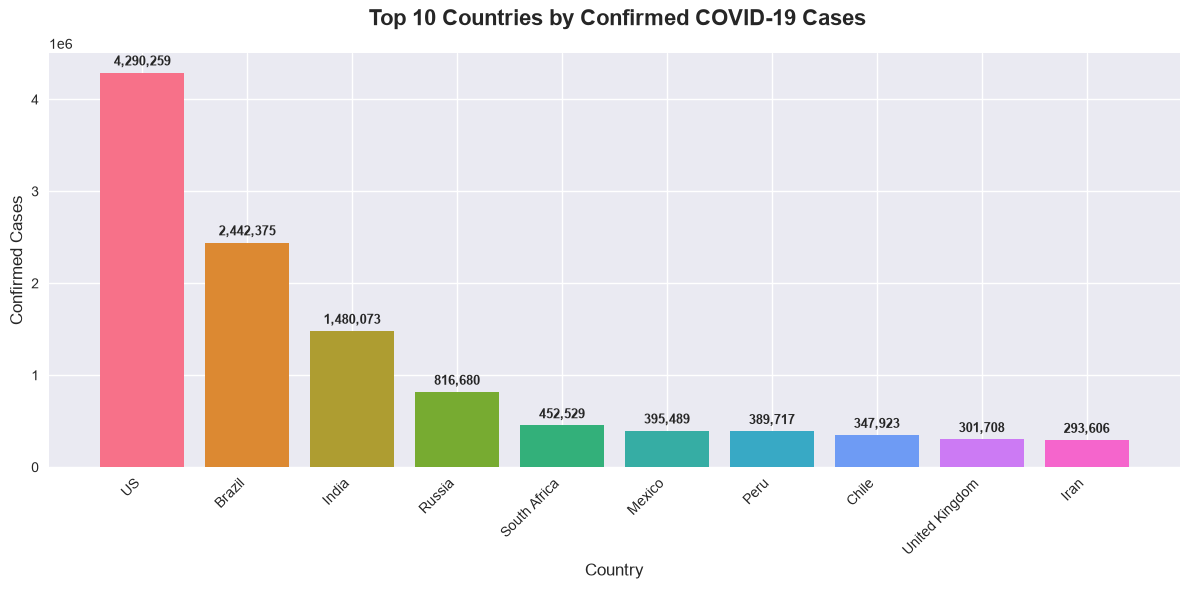

 Chart 1 Done!

 Top 3 Countries:
Country
US        4290259
Brazil    2442375
India     1480073


In [24]:
#Chart 1
latest = df[df['Date'] == df['Date'].max()]

top10 = latest.groupby('Country')['Confirmed']\
              .sum()\
              .sort_values(ascending=False)\
              .head(10)


plt.figure(figsize=(12,6))
bars = plt.bar(top10.index,
            top10.values,
            color=sns.color_palette("husl", 10))

#Add value labels on top of each bar 
for bar, value in zip(bars, top10.values):
    plt.text(bar.get_x() + bar.get_width()/2,
        bar.get_height() + 50000, f'{value:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title(' Top 10 Countries by Confirmed COVID-19 Cases',
        fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Confirmed Cases', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/chart1_top10_countries.png', dpi=150)
plt.show()

print(" Chart 1 Done!")
print(f"\n Top 3 Countries:")
print(top10.head(3).to_string())

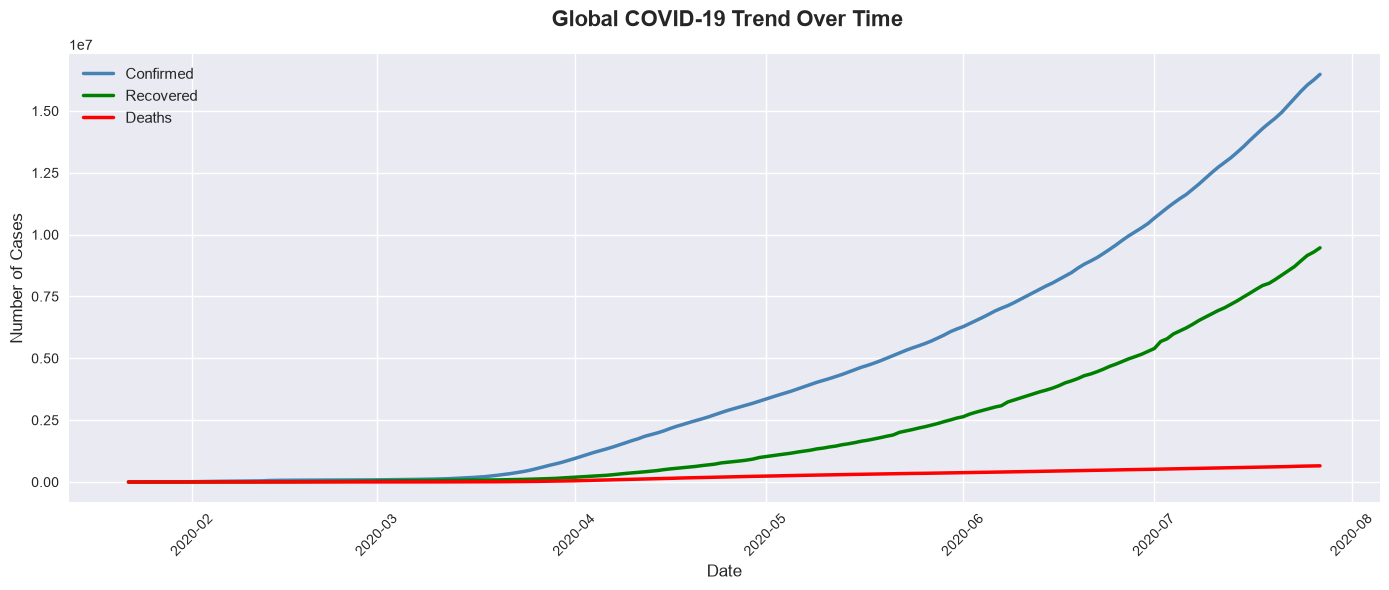

Chart 2 Done

 Final day totals:
            Confirmed  Deaths  Recovered
Date                                    
2020-07-27   16480485  654036    9468087


In [27]:
#CHART 2: Global Confirmed Cases Over Time


global_trend = df.groupby('Date')[['Confirmed','Deaths','Recovered']].sum()

# Create line chart
plt.figure(figsize=(14,6))

plt.plot(global_trend.index,global_trend['Confirmed'],color='steelblue',linewidth=2.5,label='Confirmed')

plt.plot(global_trend.index,global_trend['Recovered'],color='green',linewidth=2.5,label='Recovered')

plt.plot(global_trend.index,global_trend['Deaths'],color='red',linewidth=2.5,label='Deaths')

plt.title(' Global COVID-19 Trend Over Time',fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Cases', fontsize=12)
plt.legend(fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/chart2_global_trend.png', dpi=150)
plt.show()

print("Chart 2 Done")
print(f"\n Final day totals:")
print(global_trend.tail(1).to_string())